# Analysis Offline Inference

In [2]:
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

HERE = Path(os.getcwd())
PATH_DATA = HERE.parent / '01_aggregated_datasets' / 'inference_offline_llama3_70b'

In [3]:
from utilities import plot_setup, plot_options_default, save_figure, set_min_ticks

In [4]:
# plotting options
_ = plot_setup(plot_options_default)

## Read Data

In [5]:
# path for data
path_results = PATH_DATA / 'metadata.csv'

# save path
output_directory = HERE / "plots" 
save_flag = 1

In [6]:
df_results = pd.read_csv(path_results)
print(df_results.columns)
df_results

Index(['batch_size', 'elapsed', 'end_time', 'max_output_tokens', 'repeat',
       'seed', 'start_time', 'path_run', 'peak_power[W]', 'mean_power[W]'],
      dtype='object')


,batch_size,elapsed,end_time,max_output_tokens,repeat,seed,start_time,path_run,peak_power[W],mean_power[W]
0,550,51.138686,2025-09-18 16:31:03.916427,1024,0,2854,2025-09-18 16:30:12.777741,/projects/aiuserapps/genai_power_dataset/01_ag...,3053.759065,2822.104293
1,550,47.384165,2025-09-18 16:31:53.300838,1024,1,2854,2025-09-18 16:31:05.916673,/projects/aiuserapps/genai_power_dataset/01_ag...,3048.839824,2814.350863
2,550,48.965850,2025-09-18 16:32:44.266972,1024,2,2854,2025-09-18 16:31:55.301122,/projects/aiuserapps/genai_power_dataset/01_ag...,3042.525523,2798.014121
3,275,31.404551,2025-09-18 16:33:17.671786,1024,0,11754,2025-09-18 16:32:46.267235,/projects/aiuserapps/genai_power_dataset/01_ag...,3035.128515,2694.764568
4,275,29.579327,2025-09-18 16:33:49.251336,1024,1,11754,2025-09-18 16:33:19.672009,/projects/aiuserapps/genai_power_dataset/01_ag...,2855.922293,2696.992151
...,...,...,...,...,...,...,...,...,...,...
1195,100,11.597851,2025-09-19 06:22:15.109806,512,1,993782,2025-09-19 06:22:03.511955,/projects/aiuserapps/genai_power_dataset/01_ag...,2504.880253,2335.804795
1196,100,11.652949,2025-09-19 06:22:28.763091,512,2,993782,2025-09-19 06:22:17.110142,/projects/aiuserapps/genai_power_dataset/01_ag...,2454.062526,2320.915542
1197,650,37.835401,2025-09-19 06:23:08.598740,512,0,998016,2025-09-19 06:22:30.763339,/projects/aiuserapps/genai_power_dataset/01_ag...,3050.296412,2778.663458
1198,650,33.665365,2025-09-19 06:23:44.264465,512,1,998016,2025-09-19 06:23:10.599100,/projects/aiuserapps/genai_power_dataset/01_ag...,2889.289532,2737.807672


In [7]:
# add seed_ column
df_results["seed_"] = (
    df_results
    .groupby(["batch_size", "max_output_tokens", "repeat"])
    .cumcount()
)

In [8]:
# calculate other metrics
run_ids = df_results.to_dict(orient="records")
res = []

for row in run_ids:
    
    filepath = Path(row["path_run"])
    df = pd.read_parquet(filepath)

    # save information to plot
    d = {
        "time": df.index[-1],
        "power_avg": df["power[W]"].mean(numeric_only=True)*1e-3,
        "power_std": df["power[W]"].std(numeric_only=True)*1e-3,
        "energy": ((df["power[W]"]*1e-3)/(10*60*60)).sum(),
        "batch_size": row["batch_size"],
        "output_token_length":row["max_output_tokens"],
        "seed":row["seed_"],
        "repeat":row["repeat"]
    }

    res.append(
        {
            **row,
            **d
        }
    )
        
    df_results = pd.DataFrame(res)

# Aggregated Plots

In [9]:
df_plot_mean = df_results.pivot_table(
    index="batch_size",
    columns=["output_token_length"],
    values="time", 
    aggfunc="median"
)

In [10]:
def plot_performance_metrics(
    fig, ax,
    df_results, 
    value, 
    index="batch_size", 
    aggfunc="median"
    ):
    
    # pivot column
    columns = ["output_token_length"]
    
    # Compute statistics
    df_plot_mean = df_results.pivot_table(
        index=index,
        columns=columns,
        values=value["value"], 
        aggfunc=aggfunc
    )
    
    df_plot_low = df_results.pivot_table(
        index=index,
        columns=columns,
        values=value["value"], 
        aggfunc=lambda x: np.nanpercentile(x, 10)
    )
    
    df_plot_high = df_results.pivot_table(
        index=index,
        columns=columns,
        values=value["value"], 
        aggfunc=lambda x: np.nanpercentile(x, 90)
    )
    
    # Store handles and labels for legend
    handles, labels = None, None
            
    # Filter data for this dataset
    data_mean = (df_plot_mean * value["scale"])
    data_min = (df_plot_low * value["scale"])
    data_max = (df_plot_high * value["scale"])
    
    # Plot mean lines and get colors
    lines = data_mean.plot(marker=".", ax=ax, legend=False)
    
    # Get handles and labels from first plot
    if handles is None and labels is None:
        handles, labels = ax.get_legend_handles_labels()
    
    # Add shaded areas for each series
    for col in data_mean.columns:
        # Get the color of the corresponding line
        line_color = lines.get_lines()[list(data_mean.columns).index(col)].get_color()
        
        # Fill between min and max
        ax.fill_between(
            data_mean.index,
            data_min[col],
            data_max[col],
            color=line_color,
            alpha=0.2,
            linewidth=0
        )
    
    ax.set_xlabel("Requests Rate (Prompts/second)")
    ax.set_ylabel(value["label"])
    
    plt.tight_layout()
    
    return fig, ax, handles, labels

Saved: /kfs2/projects/aiuserapps/genai_power_dataset/02_analysis_scripts/plots/2026-03-24_offline_inference_aggregated.png


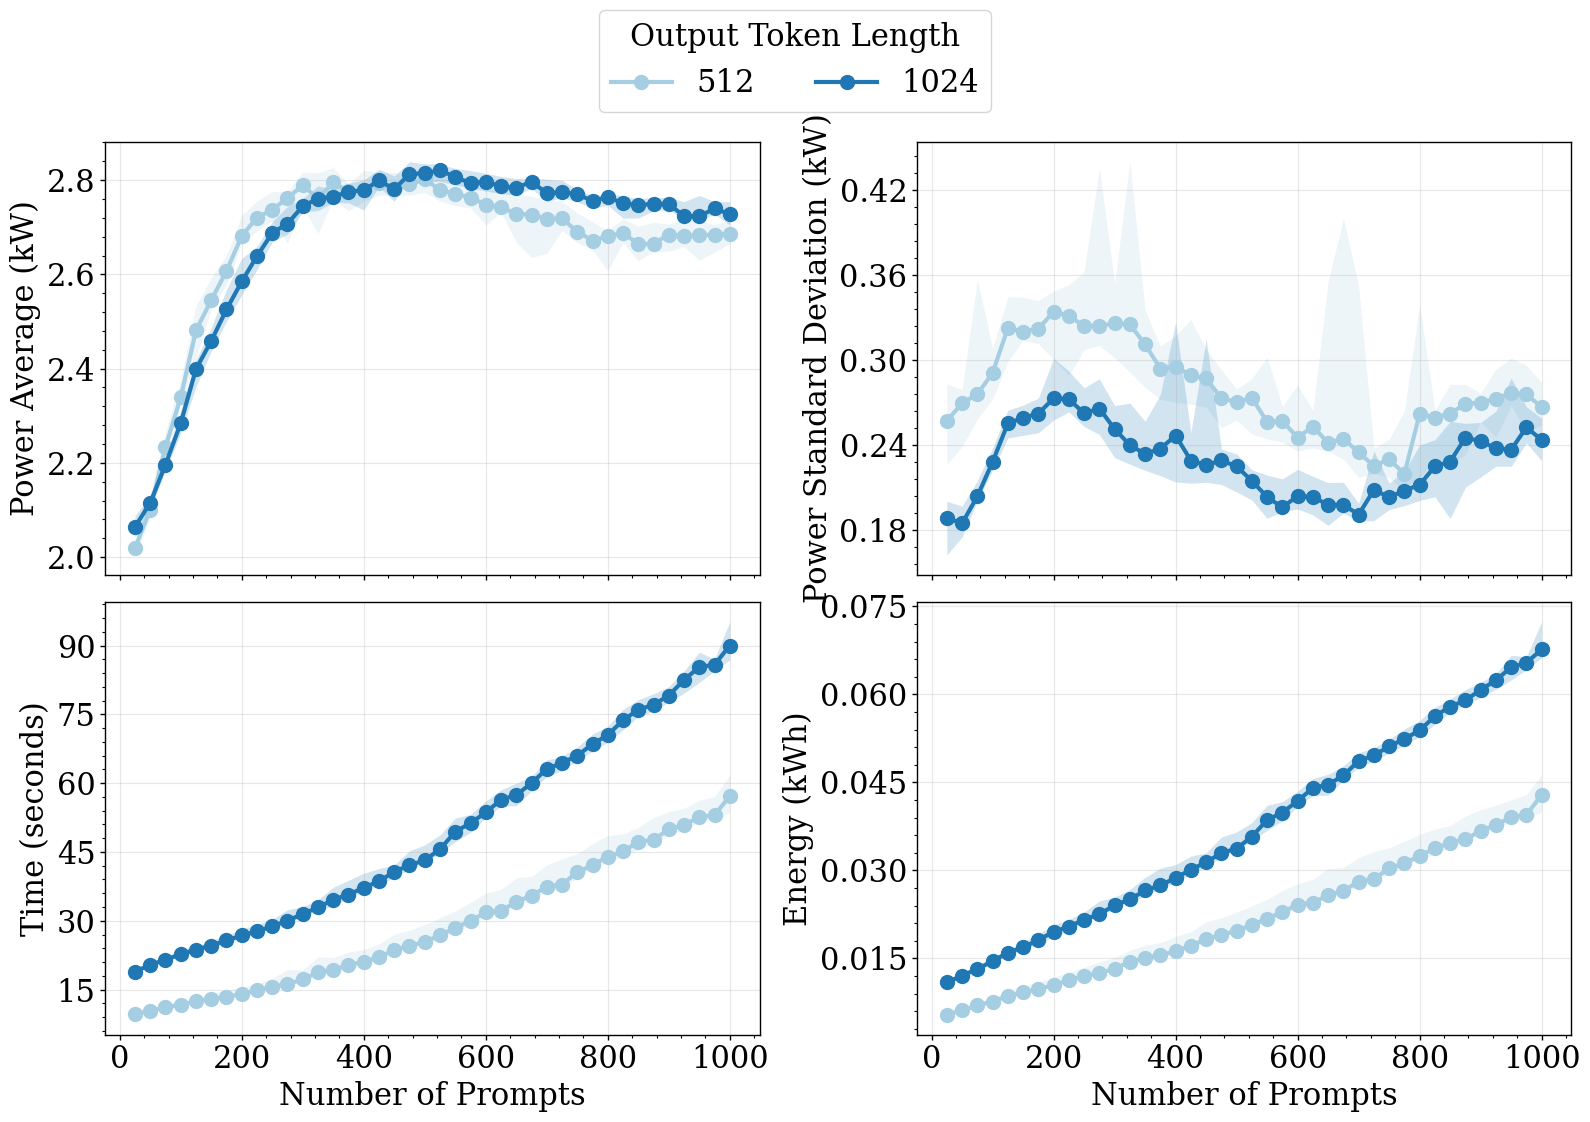

In [11]:
# Create the figure
fig, axes = plt.subplots(2,2, figsize=(16, 10), sharex=True)
ax1, ax2, ax3, ax4 = axes.flatten()

# ---------------------
values = {
    "value":"power_avg", 
    "label": "Power Average (kW)",
    "scale": 1
}
fig, ax1, handles, labels = plot_performance_metrics(
    fig, ax1,
    df_results=df_results,
    value=values,
    aggfunc="median"
)

# ---------------------
values = {
    "value":"power_std", 
    "label": 'Power Standard Deviation (kW)',
    "scale": 1
}
fig, ax2, handles, labels = plot_performance_metrics(
    fig, ax2,
    df_results=df_results,
    value=values,
    aggfunc="median"
)

# ---------------------
values = {
    "value":"time", 
    "label": "Time (seconds)",
    "scale": 1
}
fig, ax3, handles, labels = plot_performance_metrics(
    fig, ax3,
    df_results=df_results,
    value=values,
    aggfunc="median"
)

# ---------------------
values = {
    "value":"energy", 
    "label": 'Energy (kWh)',
    "scale": 1
}
fig, ax4, handles, labels = plot_performance_metrics(
    fig, ax4,
    df_results=df_results,
    value=values,
    aggfunc="median"
)


# Add a single legend below the figure
fig.legend(
    handles, 
    labels, 
    loc='lower center', 
    bbox_to_anchor=(0.5, 1), 
    ncol=len(labels), 
    title="Output Token Length"
)

for ax in axes.flatten():
    ax.set_xlabel('Number of Prompts')
    ax.grid(False, which='minor')
    ax.grid(which='major', alpha=0.3)
    ax = set_min_ticks(ax, "y", "major", 5)
    ax = set_min_ticks(ax, "y", "minor", 5)
    ax = set_min_ticks(ax, "x", "minor", 5)
    # ax.set_xscale("log")
    
# Adjust layout
plt.tight_layout()

save_figure(
    fig=fig,
    plot_name="offline_inference_aggregated",
    file_format=["png"],  # ["svg", "png", "pdf"]
    full_path=output_directory,
    save_flag=save_flag
)


# Power Profiles Plots

Saved: /kfs2/projects/aiuserapps/genai_power_dataset/02_analysis_scripts/plots/2026-03-24_offline_inference_power.png


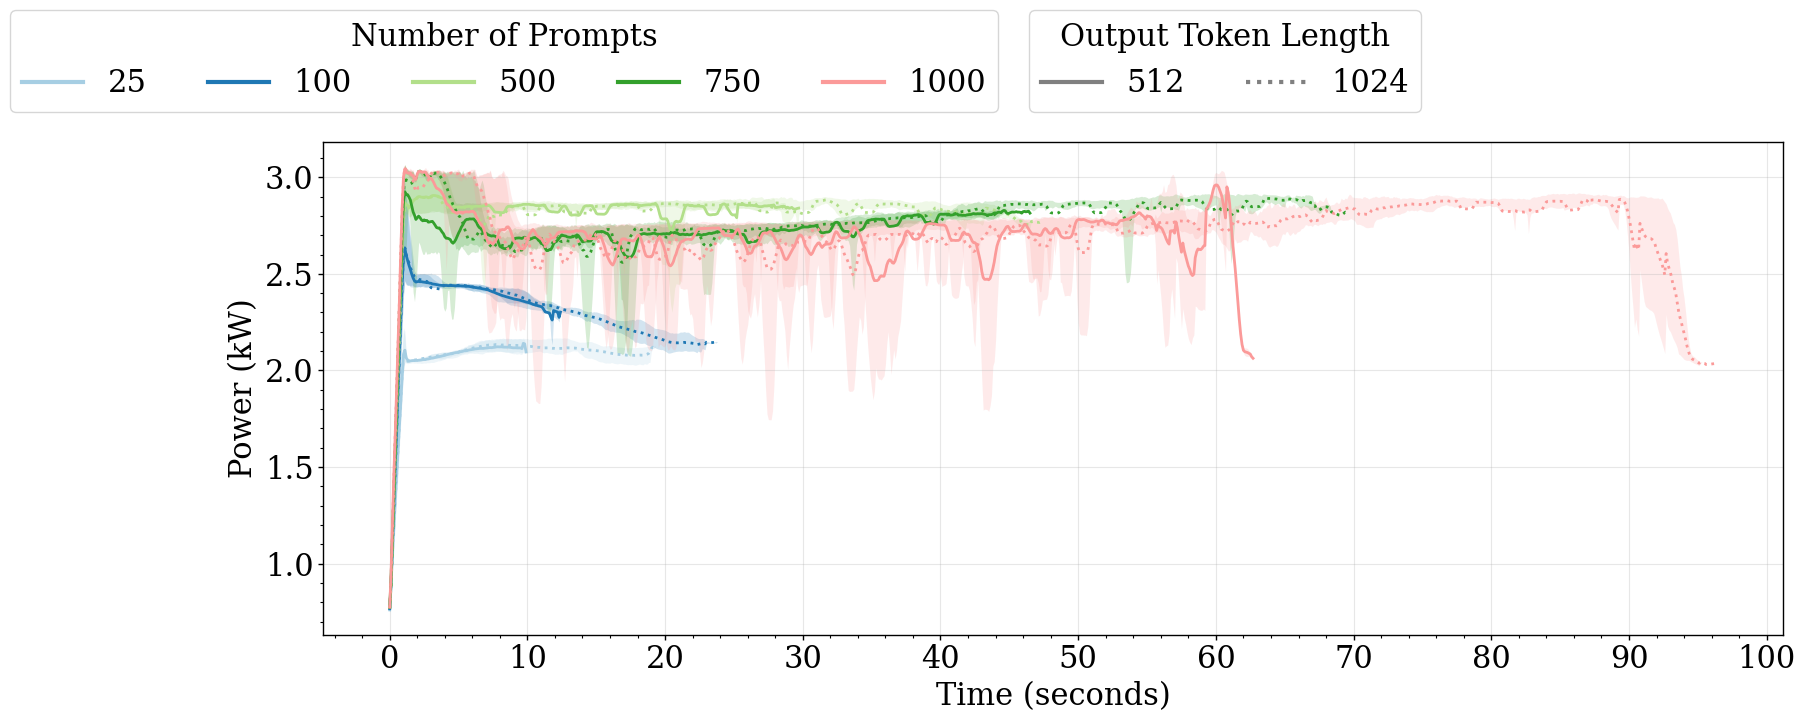

In [12]:
# Configuration
color_col = "batch_size"
linestyle_col = "output_token_length"
request_rates_to_plot = [25, 100, 500, 750, 1000]

# Filter data
df_filtered = df_results[df_results[color_col].isin(request_rates_to_plot)]

# Get unique values and assign colors
unique_colors = sorted(df_filtered[color_col].unique())
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
color_map = {val: colors[i % len(colors)] for i, val in enumerate(unique_colors)}

# Get unique values and assign linestyles
unique_linestyles = sorted(df_filtered[linestyle_col].unique())
linestyles = ['-', ':', '--', '-.']
linestyle_map = {val: linestyles[i % len(linestyles)] for i, val in enumerate(unique_linestyles)}

# Single subplot
fig, ax = plt.subplots(1, 1, figsize=(16, 6), sharey=True, sharex=True)

# Store handles and labels for legend
handles_dict = {}
labels_dict = {}

# Load timeseries grouped by color and linestyle columns
for (color_val, linestyle_val), group_df in df_filtered.groupby([color_col, linestyle_col]):
    color = color_map[color_val]
    linestyle = linestyle_map[linestyle_val]
    label = f"Rate={color_val}, Output={linestyle_val}"
    
    # Load all timeseries for this group
    all_timeseries = []
    for _, row in group_df.iterrows():
        paths = row["path_run"] if isinstance(row["path_run"], list) else [row["path_run"]]
        for run_path in paths:
            ts = pd.read_parquet(run_path)["power[W]"] * 1e-3  # Convert to kW
            ts.index = ts.index.round(4)
            all_timeseries.append(ts)
    
    # Combine all timeseries and compute statistics
    if len(all_timeseries) > 0:
        df_combined = pd.concat(all_timeseries, axis=1)
        mean_series = df_combined.mean(axis=1)
        p10_series = df_combined.quantile(0.1, axis=1)
        p90_series = df_combined.quantile(0.9, axis=1)
        
        # Plot mean series
        line, = ax.plot(
            mean_series.index,
            mean_series.values,
            color=color,
            linestyle=linestyle,
            linewidth=2,
            alpha=1,
        )
        
        # Plot shaded area for 10th-90th percentile
        ax.fill_between(
            mean_series.index,
            p10_series.values,
            p90_series.values,
            color=color,
            alpha=0.2,
            linewidth=0,
        )
        
        group_key = (color_val, linestyle_val)
        if group_key not in handles_dict:
            handles_dict[group_key] = line
            labels_dict[group_key] = label

ax.set_ylabel("Power (kW)")
ax.set_xlabel("Time (seconds)")
ax.grid(alpha=0.3)

# Create separate legends for colors and linestyles
color_handles = []
color_labels = []
for color_val in sorted(unique_colors):
    line = plt.Line2D([0], [0], color=color_map[color_val], linestyle='-', linewidth=3)
    color_handles.append(line)
    color_labels.append(f"{color_val}")

linestyle_handles = []
linestyle_labels = []
for linestyle_val in sorted(unique_linestyles):
    line = plt.Line2D([0], [0], color='gray', linestyle=linestyle_map[linestyle_val], linewidth=3)
    linestyle_handles.append(line)
    linestyle_labels.append(f"{linestyle_val}")

legend1 = fig.legend(
    color_handles,
    color_labels,
    loc='lower right',
    bbox_to_anchor=(0.5, 1),
    ncol=min(len(color_labels), 5),
    frameon=True,
    title="Number of Prompts",
)

legend2 = fig.legend(
    linestyle_handles,
    linestyle_labels,
    loc='lower left',
    bbox_to_anchor=(0.5, 1),
    ncol=min(len(linestyle_labels), 5),
    frameon=True,
    title="Output Token Length",
)

ax = set_min_ticks(ax, "y", "major", 5)
ax = set_min_ticks(ax, "y", "minor", 5)
ax = set_min_ticks(ax, "x", "major", 10)
ax = set_min_ticks(ax, "x", "minor", 5)

plt.tight_layout()

save_figure(
    fig=fig,
    plot_name="offline_inference_power",
    file_format=["png"],  # ["svg", "png", "pdf"],
    full_path=output_directory,
    save_flag=save_flag
)